# Data Exploration Notebook

In [1]:
import os

os.chdir("..") # to match paths from the root of the project

## File Structure

In [2]:
from pathlib import Path

DATA_PATH_ROOT = Path("../data_det_public/data_det_public") # Change this if data are elsewhere
assert DATA_PATH_ROOT.exists(), "Cannot find the data"

Observe file structure:

In [3]:
def print_tree(path: Path, prefix: str="", depth:int=0, max_depth:int|None=None) -> None:
    if max_depth == depth:
        return

    print(prefix + path.name)
    if path.is_dir():
        for child in sorted(path.iterdir()):
            print_tree(child, prefix + "    ", depth + 1, max_depth)

In [4]:
print_tree(DATA_PATH_ROOT, max_depth=3)

data_det_public
    bbox
        aachen
        bochum
        bremen
        cologne
        darmstadt
        dusseldorf
        erfurt
        frankfurt
        hamburg
        hanover
        jena
        krefeld
        lindau
        monchengladbach
        munster
        strasbourg
        stuttgart
        tubingen
        ulm
        weimar
        zurich
    img
        aachen
        bochum
        bremen
        cologne
        darmstadt
        dusseldorf
        erfurt
        frankfurt
        hamburg
        hanover
        jena
        krefeld
        lindau
        monchengladbach
        munster
        strasbourg
        stuttgart
        tubingen
        ulm
        weimar
        zurich
    License.txt


We have a set of images with corresponding bounding boxes structured under respective cities.

## Counts & Sizes

In [5]:
BBOX_PATH = DATA_PATH_ROOT / "bbox"
IMAGES_PATH = DATA_PATH_ROOT / "img"

In [6]:
all_images = list(IMAGES_PATH.rglob("*.png"))
all_bboxes = list(BBOX_PATH.rglob("*.csv"))

print("Number of images:", len(all_images))
print("Number of bboxes:", len(all_bboxes))

Number of images: 2590
Number of bboxes: 2590


In [23]:
total = 0

counts = {}
for city in IMAGES_PATH.iterdir():
    n_ims = len(list(city.glob("*.png")))
    counts[city.name] = n_ims
    print(f"{city.name} - {n_ims}")
    total += n_ims

print("Total", total)

aachen - 132
bochum - 78
bremen - 249
cologne - 133
darmstadt - 67
dusseldorf - 167
erfurt - 72
frankfurt - 206
hamburg - 205
hanover - 149
jena - 79
krefeld - 68
lindau - 38
monchengladbach - 62
munster - 144
strasbourg - 227
stuttgart - 163
tubingen - 96
ulm - 67
weimar - 95
zurich - 93
Total 2590


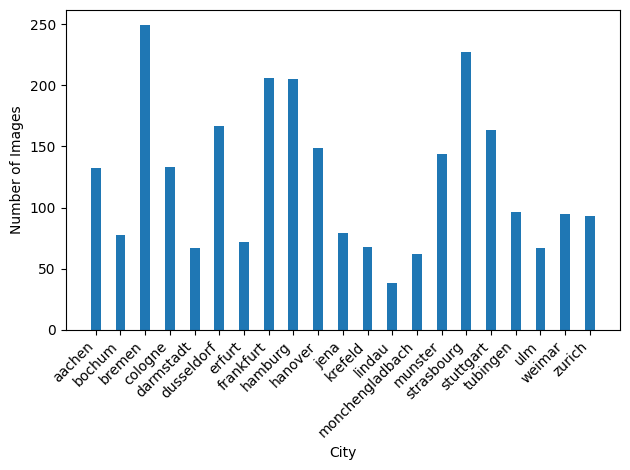

In [24]:
import matplotlib.pyplot as plt

keys = list(counts.keys())
values = list(counts.values())

plt.bar(keys, values, width=0.4)
plt.xlabel("City")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.show()

Let us observe whether size of each image is the same:

In [26]:
from PIL import Image
import numpy as np

sizes = set()

for im_path in IMAGES_PATH.rglob("*.png"):
    img = Image.open(str(im_path))
    img = np.array(img)
    sizes.add( img.shape )

sizes

{(512, 1024, 3)}

We conclude that all the images are of size `512x1024x3`

In [13]:
import pandas as pd

n_objects = []

for bbox_path in BBOX_PATH.rglob("*.csv"):
    df = pd.read_csv(str(bbox_path))
    n_objects.append(len(df))

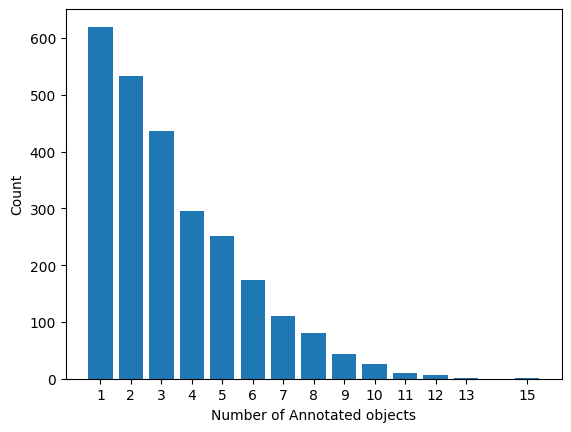

In [19]:
from collections import Counter

import matplotlib.pyplot as plt

counts = Counter(n_objects)

plt.bar(counts.keys(), counts.values())
plt.xlabel("Number of Annotated objects")
plt.ylabel("Count")
plt.xticks(sorted(set(n_objects)))
plt.show()

## Sample Observation

Observe a sample image:

In [9]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

def show_image(paths: list[Path], i: int) -> None:
    img = Image.open(str(paths[i]))
    img = np.array(img)
    print("Image size:", img.shape)
    plt.imshow(img)
    plt.axis("off")
    plt.show()

Image size: (512, 1024, 3)


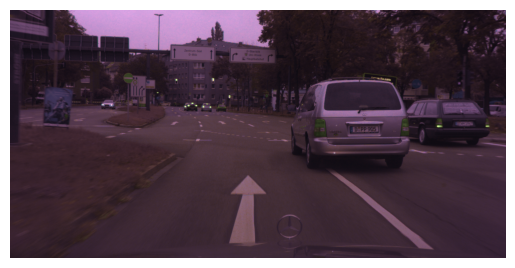

In [11]:
show_image(all_images, 752)

Since backlights on cars are usually red and we see them blue, we confirm the afore-mentioned colors transformations.

let us observe a structure of bbox file:

In [107]:
import pandas as pd

def get_bbox_df(paths: list[Path], i: int) -> pd.DataFrame:
    return pd.read_csv( str(paths[i]) )

In [108]:
sample_df = get_bbox_df(all_bboxes, 752)
sample_df

,filename,class,object_id,xmin,ymin,xmax,ymax
0,dusseldorf_000134_000019_leftImg8bit.png,vehicle,0,819,185,991,282
1,dusseldorf_000134_000019_leftImg8bit.png,vehicle,1,576,143,827,330


Let us observe how many classes in general are we going to work with:

In [109]:
classes = set()
for i in range( len(all_bboxes) ):
    classes |= set( get_bbox_df(all_bboxes, i)["class"].unique() )

print(classes)

{'vehicle'}


We confirm that we are going to detect vehicles only.

Let us observe some samples with respective bboxes:

In [110]:
import matplotlib.patches as patches
import random


def show_images_with_bboxes(image_paths: list[Path], bbox_paths: list[Path], n_samples: int=16, seed: int=42) -> None:
    random.seed(seed)

    n_samples = min(n_samples, len(image_paths))
    sample_indices = random.sample(range(len(image_paths)), n_samples)
    
    for idx in sample_indices:
        img = Image.open(image_paths[idx])
        img_np = np.array(img)

        df = get_bbox_df(bbox_paths, idx)

        fig, ax = plt.subplots(1)
        ax.imshow(img_np)
        
        for _, row in df.iterrows():
            xmin, xmax = row["xmin"], row["xmax"]
            ymin, ymax = row["ymin"], row["ymax"]
            obj_id = row["object_id"]
            
            rect = patches.Rectangle(
                (xmin, ymin), xmax-xmin, ymax-ymin,
                linewidth=2, edgecolor="red", facecolor="none"
            )
            ax.add_patch(rect)
            ax.text(xmin, ymin-2, str(obj_id), color="yellow", fontsize=12, backgroundcolor="black")
        
        ax.axis("off")
        plt.show()

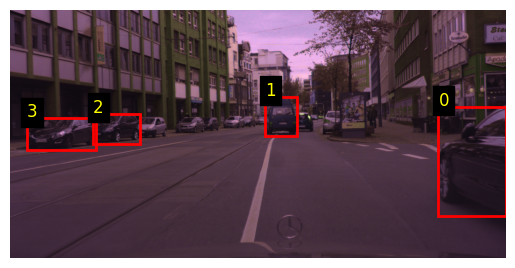

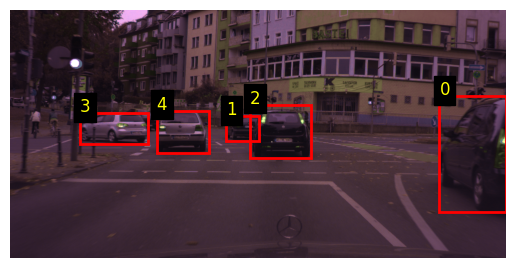

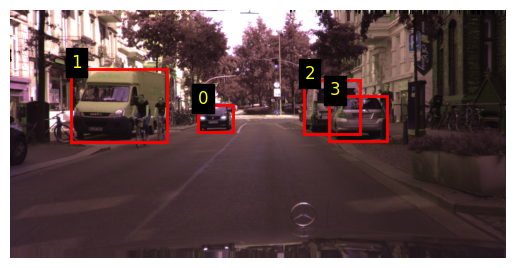

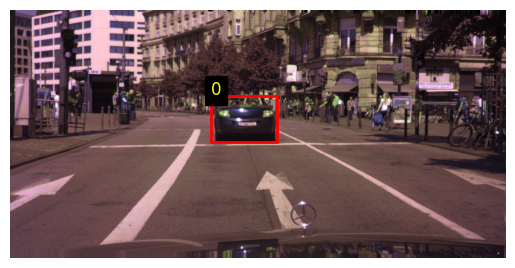

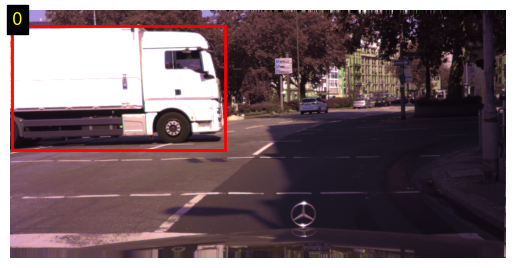

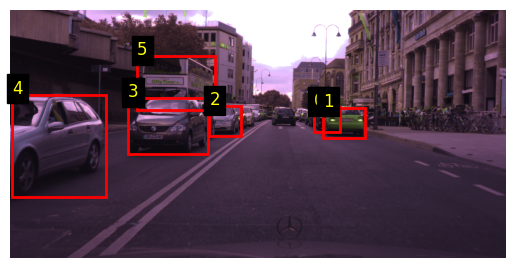

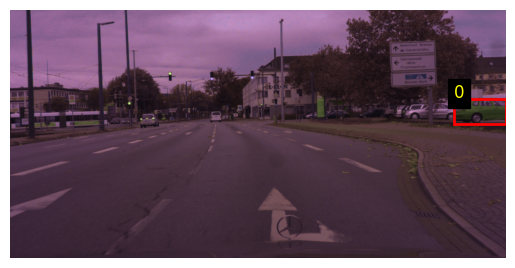

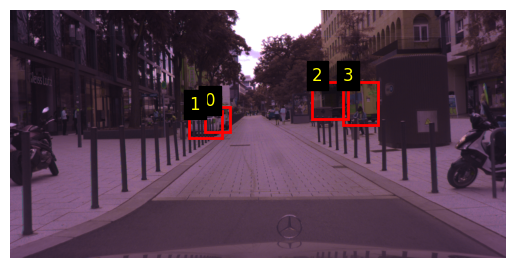

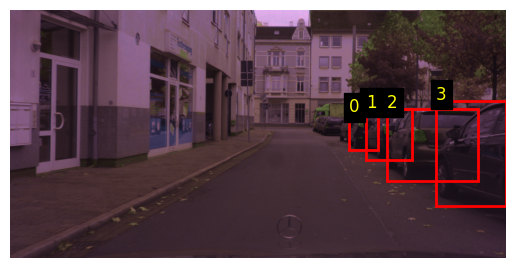

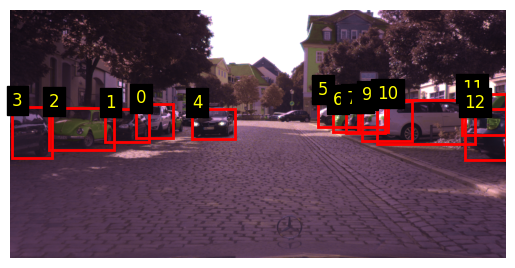

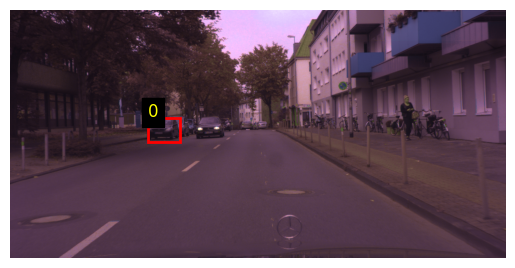

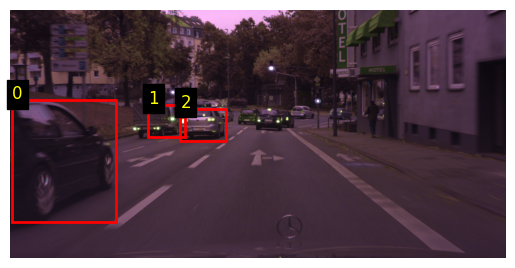

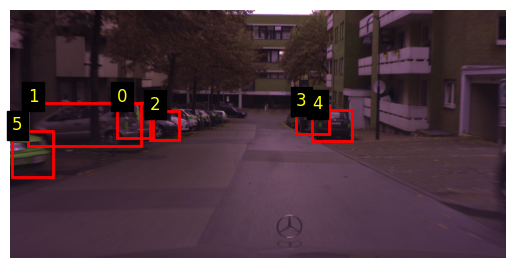

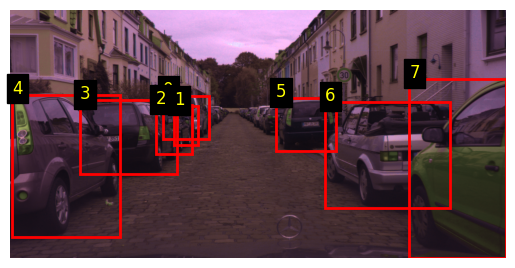

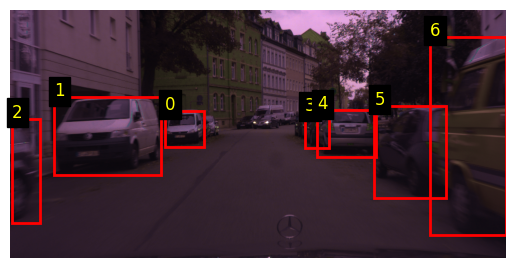

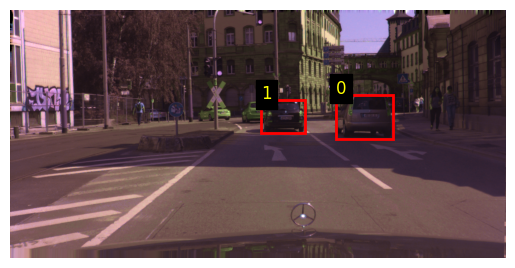

In [111]:
show_images_with_bboxes(all_images, all_bboxes, 16)

We can see only some of the vehicles on the pictures are annotated. This is very important information for the evaluation of our models.

## Create Final CSV

In [9]:
import pandas as pd

images = IMAGES_PATH.rglob("*.png")
bboxes = BBOX_PATH.rglob("*.csv")

data = {
    "image_path": [],
    "bbox_path": [],
    "city": [],
    "n_objects": [],
}

for im_path, bbox_path in zip(images, bboxes):
    data["image_path"].append( str(im_path) )
    data["bbox_path"].append( str(bbox_path) )
    data["city"].append( im_path.parent.name )
    data["n_objects"].append( len(pd.read_csv( str(bbox_path) )) )

final_df = pd.DataFrame(data)
final_df.to_csv("data_explored.csv", index=False)

In [8]:
final_df.head()

,image_path,bbox_path,city,n_objects
0,..\data_det_public\data_det_public\img\aachen\...,..\data_det_public\data_det_public\bbox\aachen...,aachen,1
1,..\data_det_public\data_det_public\img\aachen\...,..\data_det_public\data_det_public\bbox\aachen...,aachen,2
2,..\data_det_public\data_det_public\img\aachen\...,..\data_det_public\data_det_public\bbox\aachen...,aachen,3
3,..\data_det_public\data_det_public\img\aachen\...,..\data_det_public\data_det_public\bbox\aachen...,aachen,1
4,..\data_det_public\data_det_public\img\aachen\...,..\data_det_public\data_det_public\bbox\aachen...,aachen,2
